# Prototyping Difference Gradient Analysis for MISalign 2.0

In [5]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as colors

In [8]:
# %matplotlib widget
%matplotlib inline

In [7]:
from misalign.model.project import MISProjectJSON
from misalign.model.relation import MISRelationRectangular
import misalign.alignment.difference_gradient as dga
import misalign.canvas.canvas_rectangular as cr

In [4]:
mis_filepath="../example/project_a/project_a-relations-calibrated.mis.json"
mis_project=MISProjectJSON.load(mis_filepath)
mis_project.find_image_paths(mis_filepath,update=True)
print(mis_project)

A misalign project with:
Images:
    image_a01.jpg
    image_a02.jpg
    image_a03.jpg
    image_a04.jpg
    image_a05.jpg
    image_a06.jpg
    image_a07.jpg
    image_a08.jpg
    image_a09.jpg
    image_a10.jpg
Relations:
    ('image_a01.jpg', 'image_a02.jpg')
    ('image_a02.jpg', 'image_a03.jpg')
    ('image_a03.jpg', 'image_a04.jpg')
    ('image_a04.jpg', 'image_a05.jpg')
    ('image_a05.jpg', 'image_a06.jpg')
    ('image_a06.jpg', 'image_a07.jpg')
    ('image_a07.jpg', 'image_a08.jpg')
    ('image_a08.jpg', 'image_a09.jpg')
    ('image_a09.jpg', 'image_a10.jpg')
Calibration:
    pixel : 600
    length : 1
    length_unit : mm
Project Path:
    ..\example\project_a\project_a-relations-calibrated.mis.json


In [10]:
plt.close('all')

In [9]:
# Using `mis_project.get_relations()[1]` which has an ideal offset of `(8, -1146)`
# We can check strategy_max_size=50 which gives 101x101=10201 offsets.
# Not including plotting the cell takes 7.3s to run.
# Using `mis_project.get_relations()[2]` which has an ideal offset of `(-124, -1060)`
# strategy_max_size=50 which gives 201x201=40401 > Not including plotting takes 16.9s to run.
# strategy_max_size=100 which gives 201x201=40401 > Not including plotting takes 67.3s to run.
# In general: Higher overlap takes more time, strategy size has squared relationship with run time.

selected_relation=mis_project.get_relations()[2] #8 is particularly far away/good to visualize # 7 is neat for seeing how physical features effect plot.
selected_dga_results=dga.difference_gradient_analysis(
        image_a=mis_project.get_image(selected_relation.get_reference()[0]),
        image_b=mis_project.get_image(selected_relation.get_reference()[1]),
        relation=selected_relation,
        strategy=dga.strategy_scaled_grid,
        metric=dga.metric_squared_mean,
        strategy_max_size=10,
        strategy_grid_scale=1,
        )
print("Initial:",selected_dga_results["initial_offset"],"Optimized:",selected_dga_results["optimized_offset"])

Initial: (-129, -1058) Optimized: (-124, -1060)


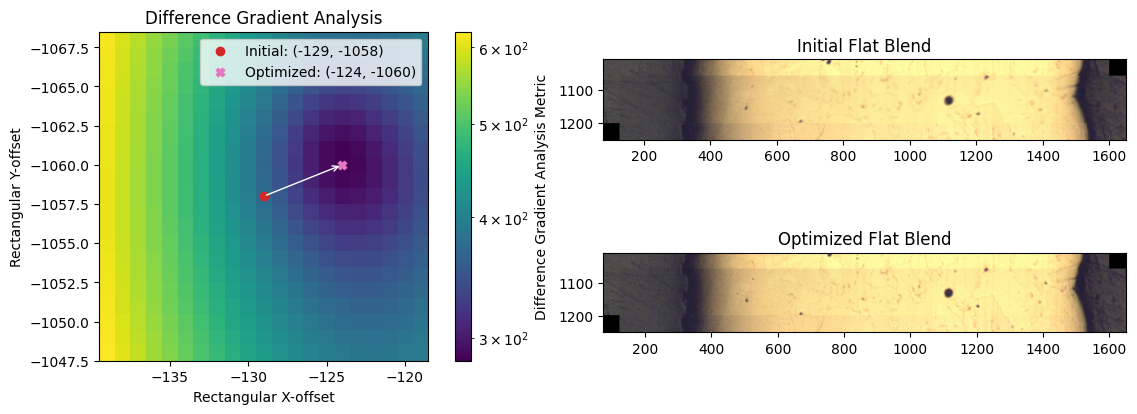

In [11]:
dga.plot_grid_difference_gradient_analysis(
        image_a=mis_project.get_image(selected_relation.get_reference()[0]),
        image_b=mis_project.get_image(selected_relation.get_reference()[1]),
        dga_grid_result=selected_dga_results,
    )
plt.show()

0 : ('image_a01.jpg', 'image_a02.jpg') (12, -1088) -> (9, -1087)


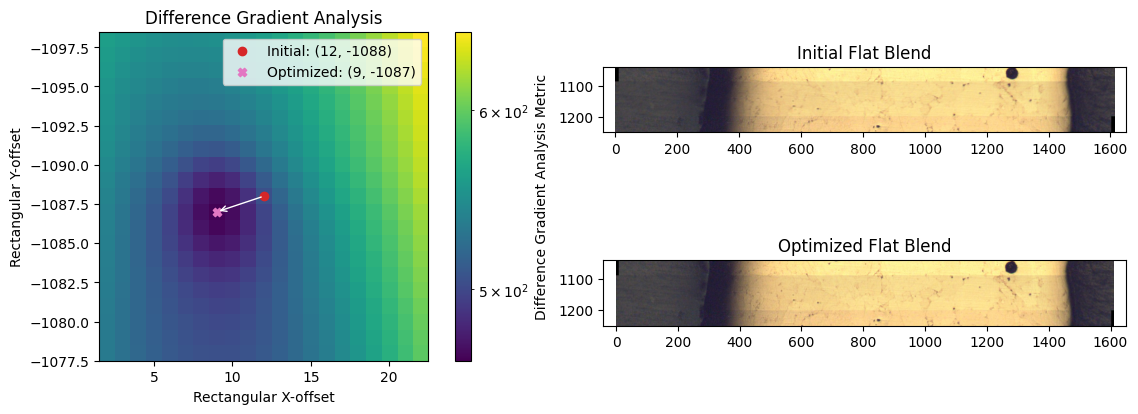

1 : ('image_a02.jpg', 'image_a03.jpg') (8, -1141) -> (8, -1146)


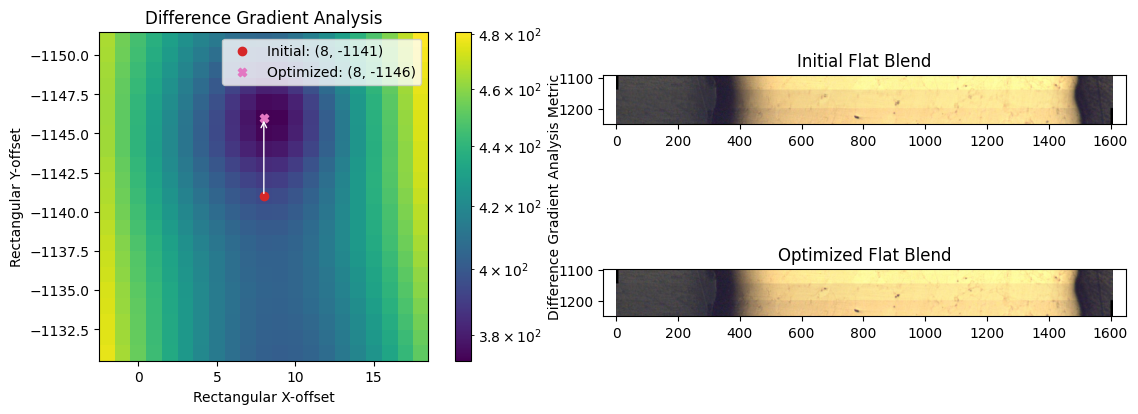

2 : ('image_a03.jpg', 'image_a04.jpg') (-129, -1058) -> (-124, -1060)


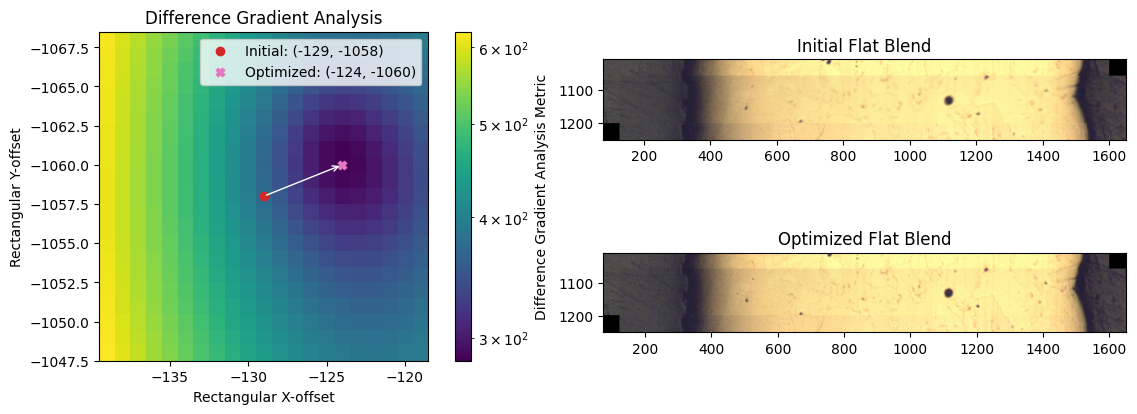

3 : ('image_a04.jpg', 'image_a05.jpg') (11, -943) -> (10, -942)


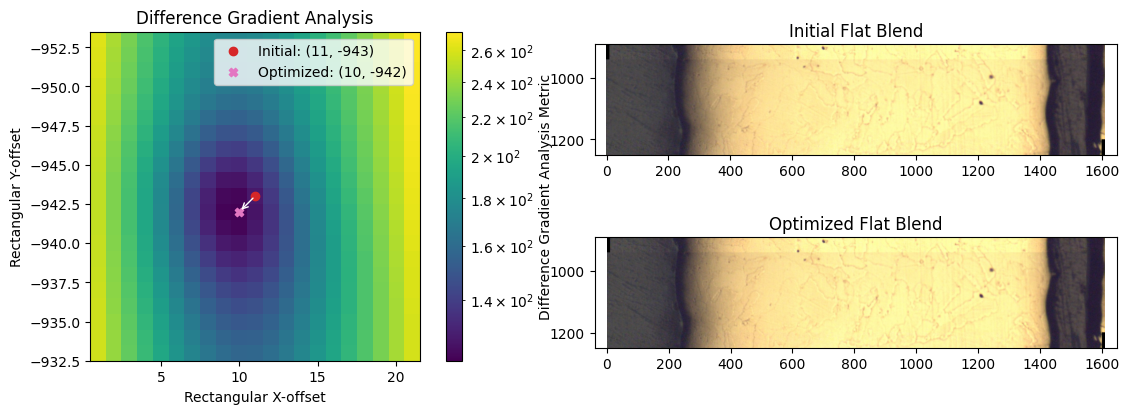

4 : ('image_a05.jpg', 'image_a06.jpg') (5, -860) -> (7, -857)


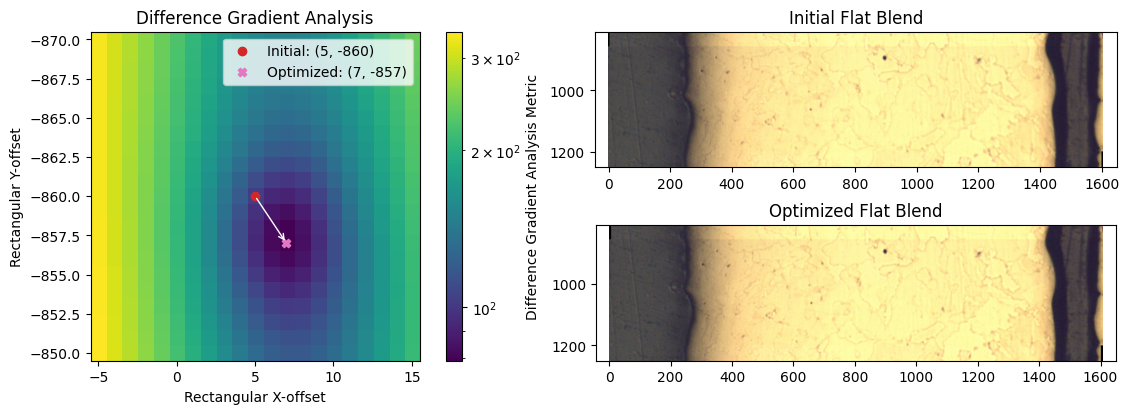

5 : ('image_a06.jpg', 'image_a07.jpg') (10, -990) -> (8, -989)


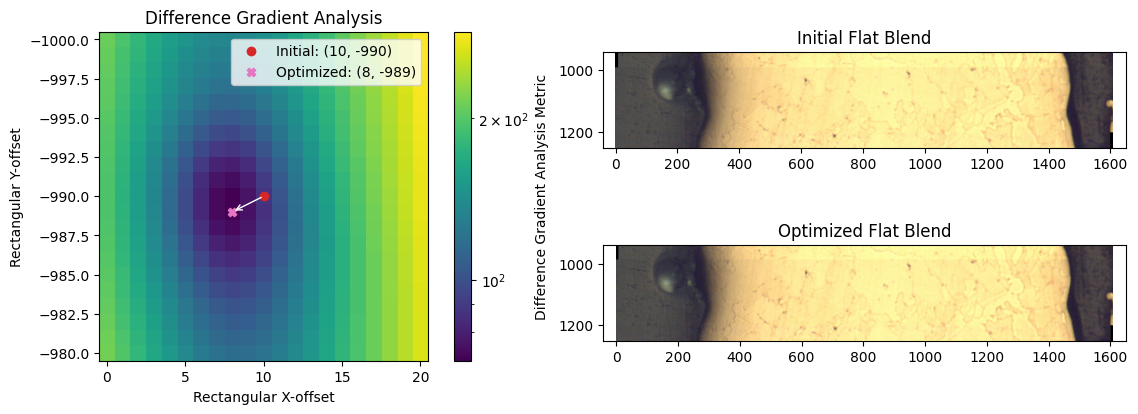

6 : ('image_a07.jpg', 'image_a08.jpg') (9, -1009) -> (8, -1008)


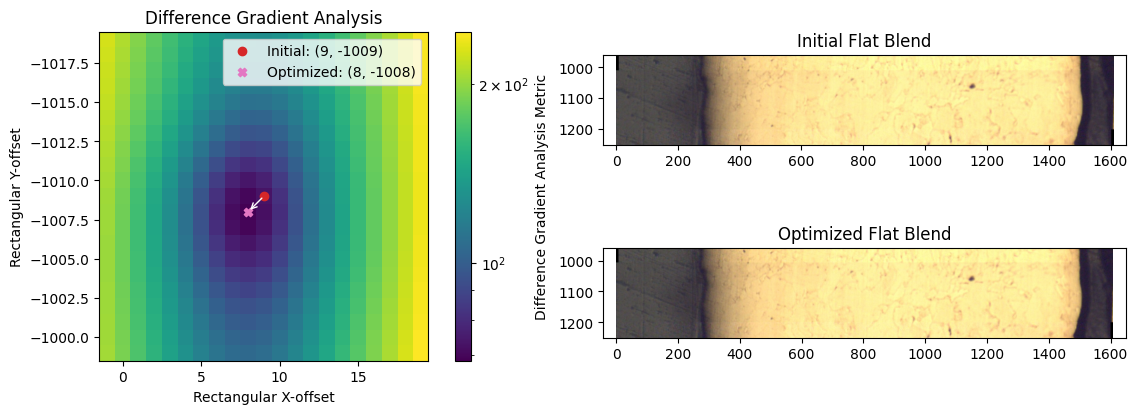

7 : ('image_a08.jpg', 'image_a09.jpg') (9, -939) -> (8, -938)


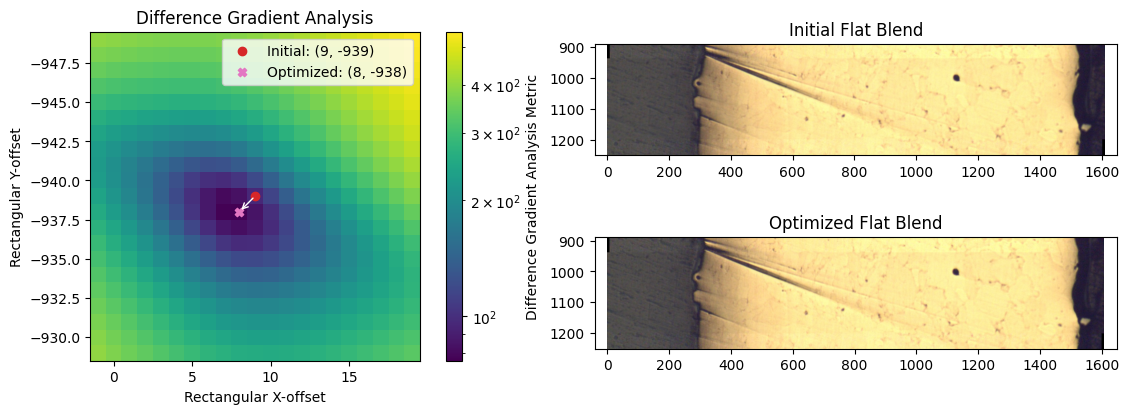

8 : ('image_a09.jpg', 'image_a10.jpg') (3, -722) -> (4, -715)


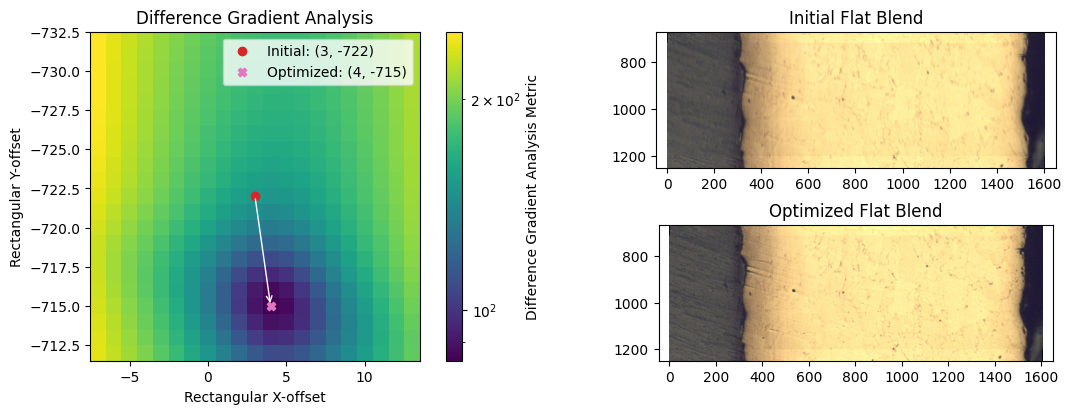

In [13]:
relation_index_results=dict()
for i,relation in enumerate(mis_project.get_relations()):
    dga_results=dga.difference_gradient_analysis(
            image_a=mis_project.get_image(relation.get_reference()[0]),
            image_b=mis_project.get_image(relation.get_reference()[1]),
            relation=relation,
            strategy=dga.strategy_full_grid,
            metric=dga.metric_squared_mean,
            strategy_max_size=10,
            )
    print(i,":",relation.get_reference(),relation.get_relation('r'),"->",dga_results["optimized_offset"])
    dga.plot_grid_difference_gradient_analysis(
        image_a=mis_project.get_image(relation.get_reference()[0]),
        image_b=mis_project.get_image(relation.get_reference()[1]),
        dga_grid_result=dga_results,
    )
    plt.show()
    

In [ ]:
# [mis_project.set_relation(i,relation) for i,relation in relation_index_results.items()]
# mis_filepath="../example/project_a/project_a-dga_relations-calibrated.mis.json"
# mis_project.save(mis_filepath)